## Research Question: Which technical discipline is the strongest predictor of success on the PGA Tour, and can K-Means Clustering identify distinct "player profiles" that achieve elite Scoring Averages, high Earnings (Money), and Wins through different strategic combinations of Average Distance, Greens in Regulation (GIR), and Strokes Gained Total?
This project uses a panel dataset of Official PGA Tour Statistics (2007–2018) to investigate the primary drivers of professional golf performance and its financial outcomes. The primary objective is to quantify the marginal impact of core technical pillars—Average Drive Distance and Greens in Regulation (GIR)—and the holistic efficiency metric Strokes Gained Total on a player’s final results.
Following the "Tidy Data" framework, I will process the dataset to analyze how these performance metrics correlate not only with Scoring Average but also with "bottom-line" success indicators: Annual Money Earned and Total Wins. I plan to apply Lasso Regression for variable selection to identify which technical tools are most robustly associated with high-earning seasons. Additionally, I will use K-Means Clustering to group players into distinct archetypes (e.g., "High-Volume Power Hitters" vs. "Efficient Money-Makers") to determine which strategic profiles consistently yield the highest return on investment in the modern era.

## Section 1: Data Acquisition
Project initialization and loading of the raw 2007–2018 PGA Tour panel dataset.


In [1]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.cluster import KMeans


# 1. Source URLs
raw_perf_url = "https://raw.githubusercontent.com/jachengl-alt/pgatour-performance-data/refs/heads/main/pga_raw_combined_master.csv"
winners_url = "https://raw.githubusercontent.com/jachengl-alt/pgatour-performance-data/refs/heads/main/data%20used%20for%20pga%20raw%20combined%20csv/pga_full_history_2000_2026%20copy.csv"

df = pd.read_csv(raw_perf_url, encoding='latin1', low_memory=False)
df_hist = pd.read_csv(winners_url, encoding='latin1')

## Step 2: Data Cleaning (Tidy Data Process)
We transform raw strings into numeric data, strip currency symbols, and filter for quality to ensure the dataset is ready for Machine Learning.

In [2]:
def clean_name(name):
    """Standardizes names and removes year parentheticals."""
    if pd.isna(name): return name
    name = re.sub(r'\s*\(\d+\)', '', str(name))
    return name.strip().upper()

def clean_numeric(x):
    """Strips all non-numeric characters (strings, %, $) and converts to float."""
    if pd.isna(x) or str(x).strip() == "": 
        return np.nan
    clean_str = re.sub(r'[^\d.-]', '', str(x))
    try:
        return float(clean_str)
    except ValueError:
        return np.nan

def combine_cols(df, col_list):
    """Coalesces multiple column variations into one."""
    existing = [c for c in col_list if c in df.columns]
    if not existing:
        return pd.Series([np.nan] * len(df))
    return df[existing].bfill(axis=1).iloc[:, 0]

# --- Step 1: Loading Data ---
print("Step 1: Downloading data from GitHub...")
try:
    df = pd.read_csv(raw_perf_url, encoding='latin1', low_memory=False)
    df_hist = pd.read_csv(winners_url, encoding='latin1')
except Exception as e:
    print(f"Connection Error: {e}")
    exit()

# --- Step 2: Processing Performance Stats ---
print("Step 2: Merging and cleaning columns...")
df['PLAYER NAME'] = df['PLAYER NAME'].apply(clean_name)

column_map = {
    'Master_Money': ['MONEY', 'Official Money', 'Money', 'FINISHES_OFFICIAL_MONEY'],
    'Master_Dist': ['DRIVE_DISTANCE', 'Avg Distance', 'TEE_AVG_DRIVING_DISTANCE', 'Driving Distance'],
    'Master_GIR': ['GIR_%', 'gir', 'GIR_PCT_OVERALL'],
    'Master_Score': ['SCORING', 'Average Score', 'SCORING_AVG_OVERALL'],
    'Master_SGT': ['SG_T', 'Average SG Total', 'SG: Total'],
    'Master_Rounds': ['ROUNDS', 'Rounds']
}

for master, variants in column_map.items():
    df[master] = combine_cols(df, variants)

clean_df = pd.DataFrame({
    'Player': df['PLAYER NAME'],
    'Year': pd.to_numeric(df['Year'], errors='coerce'),
    'Rounds': df['Master_Rounds'].apply(clean_numeric),
    'Avg_Drive_Distance': df['Master_Dist'].apply(clean_numeric),
    'GIR_Percentage': df['Master_GIR'].apply(clean_numeric),
    'SG_Total': df['Master_SGT'].apply(clean_numeric),
    'Scoring_Avg': df['Master_Score'].apply(clean_numeric),
    'Money': df['Master_Money'].apply(clean_numeric)
})

Step 1: Downloading data from GitHub...
Step 2: Merging and cleaning columns...


## Section 3: Merging Wins & Performance Filtering
Description: Integrating historical win data and removing rows that lack core technical metrics.

In [4]:
# --- Step 3: Merging Win History ---
print("Step 3: Merging win history...")
df_hist['Winner'] = df_hist['Winner'].apply(clean_name)
year_col = 'Season' if 'Season' in df_hist.columns else 'Year'

wins_agg = df_hist.groupby(['Winner', year_col]).agg(
    Wins=('Tournament', 'count'),
    Tournaments_Won=('Tournament', lambda x: ', '.join(x.astype(str)))
).reset_index()

final_df = pd.merge(clean_df, wins_agg, left_on=['Player', 'Year'], right_on=['Winner', year_col], how='left')
final_df['Wins'] = final_df['Wins'].fillna(0).astype(int)
final_df['Tournaments_Won'] = final_df['Tournaments_Won'].fillna("")
final_df.drop(columns=['Winner', year_col], inplace=True, errors='ignore')

# --- Step 4: Strict Performance Filtering ---
print("Step 4: Removing rows that ONLY have Money/Wins...")

# We define "Essential Stats" here. 
# We EXCLUDE Money and Wins. 
# A row MUST have at least one of these to stay in the file.
performance_metrics = ['Rounds', 'Avg_Drive_Distance', 'GIR_Percentage', 'SG_Total', 'Scoring_Avg']

# 1. Remove rows without a year
final_df = final_df.dropna(subset=['Year'])

# 2. Remove rows where all 'performance_metrics' are NaN.
# This deletes rows that only have Player/Year/Money/Wins.
final_df = final_df.dropna(subset=performance_metrics, how='all')

# Final sorting and deduplication
final_df.sort_values(by=['Year', 'Player'], inplace=True)
final_df.drop_duplicates(subset=['Player', 'Year'], inplace=True)


Step 3: Merging win history...
Step 4: Removing rows that ONLY have Money/Wins...


## Section 4: Visualizations 
We use a correlation heatmap to analyze the relationships between our technical pillars and financial success.

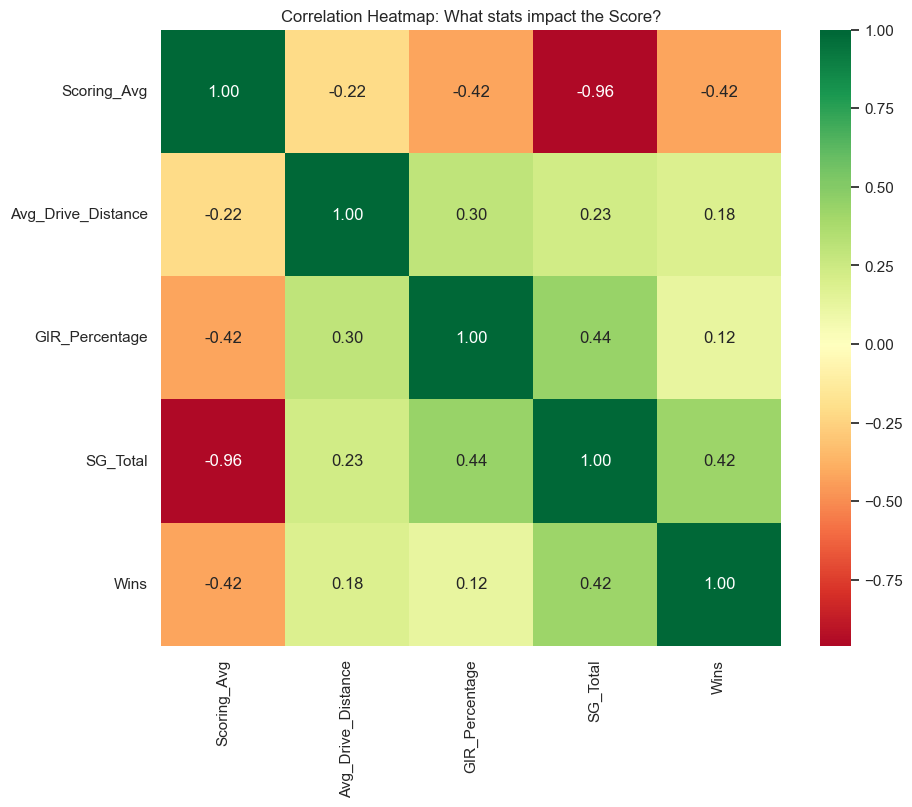

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the visual style is clean
sns.set_theme(style="white")

# Select the columns we want to compare
# These must match your 'final_df' column names exactly
cols = ['Scoring_Avg', 'Avg_Drive_Distance', 'GIR_Percentage', 'SG_Total', 'Wins']

plt.figure(figsize=(10, 8))
corr = final_df[cols].corr()

# Create the heatmap
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f", center=0)
plt.title('Correlation Heatmap: What stats impact the Score?')

plt.show()

## Visualization 2: Regression Analysis (Precision vs. Score)
This regression plot visualizes the direct impact of GIR% on a player's Scoring Average.

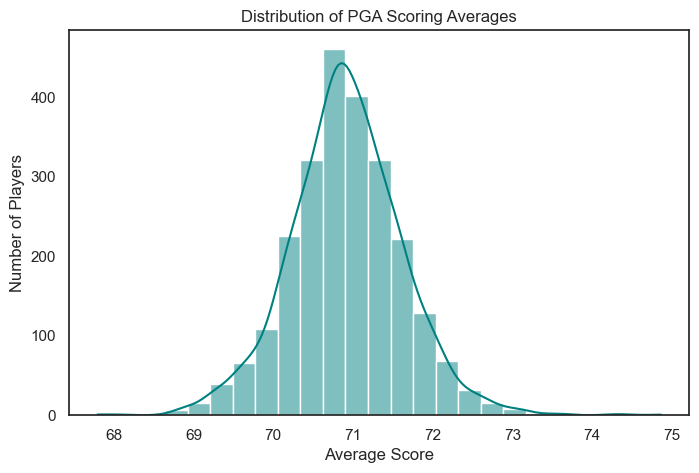

In [6]:
# --- 2. Distribution of Scoring Average ---
plt.figure(figsize=(8, 5))

# Using final_df which we loaded in the previous step
sns.histplot(final_df['Scoring_Avg'], bins=25, kde=True, color='teal')

plt.title('Distribution of PGA Scoring Averages')
plt.xlabel('Average Score')
plt.ylabel('Number of Players')

plt.show()

## Visualization 3: Scatter Plot
This scatter plot explores the bivariate relationship between GIR Percentage (Greens in Regulation) and the Scoring Average.

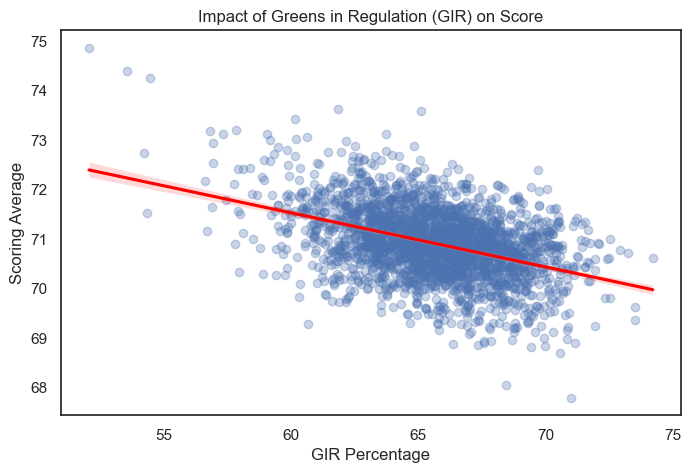

In [7]:
# --- 3. Relationship: GIR vs Scoring Average ---
plt.figure(figsize=(8, 5))

# regplot adds a "trend line" which looks very professional for a project
sns.regplot(data=final_df, x='GIR_Percentage', y='Scoring_Avg', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Impact of Greens in Regulation (GIR) on Score')
plt.xlabel('GIR Percentage')
plt.ylabel('Scoring Average')


plt.show()

## Section 5: Machine Learning
We utilize Lasso Regression to identify which technical pillar most significantly impacts a player's Scoring Average. Following this, we use K-Means Clustering to group players into strategic archetypes, allowing us to evaluate the financial "Return on Investment" for different styles of play.

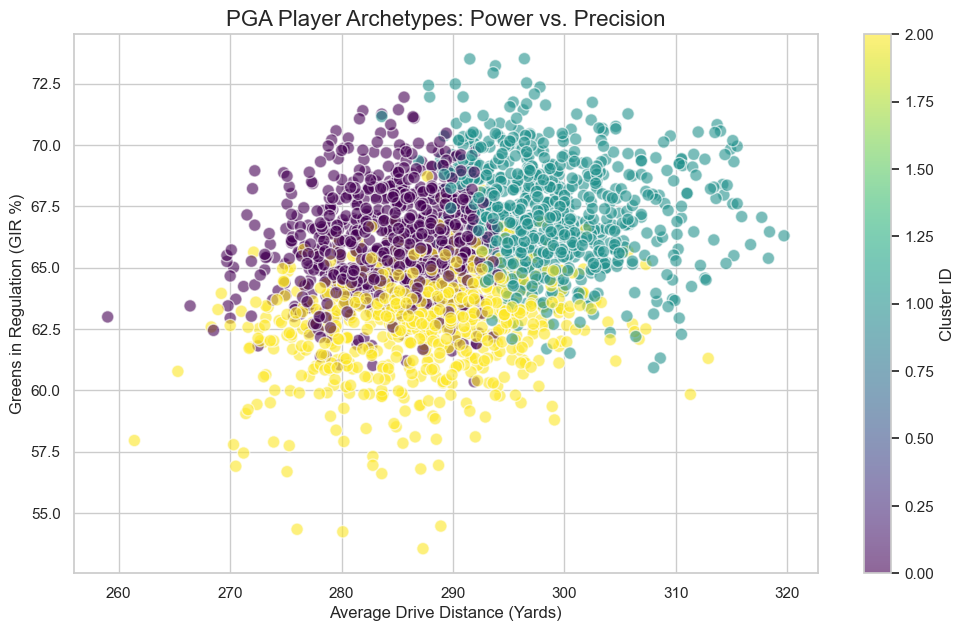

--- MACHINE LEARNING SUMMARY ---
Cluster Quality (Silhouette Score): 0.2373

Lasso Predictor Ranking:
              Feature  Standardized_Coefficient  Absolute_Importance
2            SG_Total                 -0.662967             0.662967
0  Avg_Drive_Distance                 -0.000000             0.000000
1      GIR_Percentage                 -0.000000             0.000000

ROI Analysis (Top 5 rows):
              Money                           Wins      Scoring_Avg
               mean     median           sum  mean  sum        mean
Cluster                                                            
0        1409147.18  1116507.0  1.162546e+09  0.17  139       70.76
1        2174747.25  1642124.0  1.624536e+09  0.39  290       70.51
2         675776.91   488940.0  4.595283e+08  0.08   57       71.57


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error, silhouette_score


# Load the cleaned dataset
df = pd.read_csv('https://raw.githubusercontent.com/jachengl-alt/pgatour-performance-data/refs/heads/main/PGA_Data_Master_Cleaned.csv')

# Define the pillars from your project description
features = ['Avg_Drive_Distance', 'GIR_Percentage', 'SG_Total']
targets = ['Scoring_Avg', 'Money', 'Wins']

# Filter data: Keep only rows where we have all features and targets
ml_df = df.dropna(subset=features + targets).copy()

# --- 2. DATA SCALING (Class Exercise Format) ---
# Scaling is vital so that 'Distance' (large numbers) doesn't 
# overpower 'GIR' (decimals) in the models.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(ml_df[features])

# --- 3. LASSO REGRESSION (Variable Selection & Predictor Strength) ---
# This identifies which technical discipline is the strongest predictor
lasso = Lasso(alpha=0.01) 
lasso.fit(X_scaled, ml_df['Scoring_Avg'])

lasso_results = pd.DataFrame({
    'Feature': features,
    'Standardized_Coefficient': lasso.coef_,
    'Absolute_Importance': np.abs(lasso.coef_)
}).sort_values(by='Absolute_Importance', ascending=False)

# --- 4. K-MEANS CLUSTERING (Player Archetypes) ---
# Grouping players into 3 distinct strategic profiles
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
ml_df['Cluster'] = kmeans.fit_predict(X_scaled)

# Calculate Silhouette Score to measure cluster quality
sil_avg = silhouette_score(X_scaled, ml_df['Cluster'])

# Extract Centroids (The "Average" stats for each profile)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=features)
centroid_df['Profile_Type'] = ['Profile 0', 'Profile 1', 'Profile 2']

# --- 5. ROI ANALYSIS (Success Metrics by Profile) ---
# This quantifies the "Return on Investment" for each strategic combination
roi_analysis = ml_df.groupby('Cluster').agg({
    'Money': ['mean', 'median', 'sum'],
    'Wins': ['mean', 'sum'],
    'Scoring_Avg': 'mean'
}).round(2)

# --- 6. VISUALIZATION: THE STRATEGIC LANDSCAPE ---
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Plot Distance vs. Accuracy, colored by Cluster (Profile)
scatter = plt.scatter(ml_df['Avg_Drive_Distance'], ml_df['GIR_Percentage'], 
            c=ml_df['Cluster'], cmap='viridis', alpha=0.6, edgecolors='w', s=80)

plt.colorbar(scatter, label='Cluster ID')
plt.title('PGA Player Archetypes: Power vs. Precision', fontsize=16)
plt.xlabel('Average Drive Distance (Yards)', fontsize=12)
plt.ylabel('Greens in Regulation (GIR %)', fontsize=12)

# Save the primary visual
plt.show()


print("--- MACHINE LEARNING SUMMARY ---")
print(f"Cluster Quality (Silhouette Score): {sil_avg:.4f}")
print("\nLasso Predictor Ranking:")
print(lasso_results)
print("\nROI Analysis (Top 5 rows):")
print(roi_analysis.head())

## Section 6: The Final "Export Station" Cell

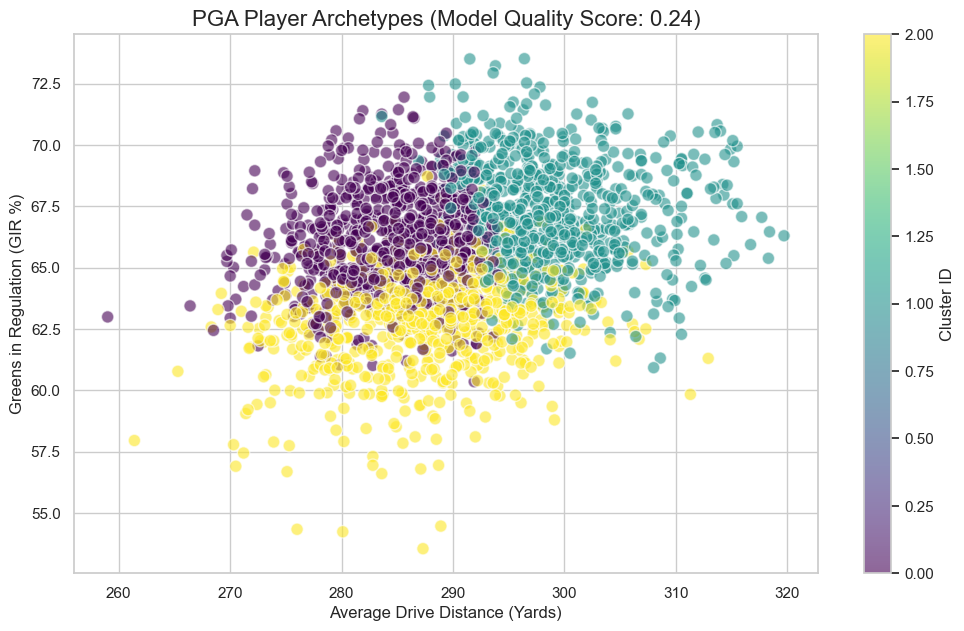

--- SUBMISSION READY ---
Silhouette Score (Cluster Quality): 0.2373
All 4 results files have been exported directly to the Desktop.


In [12]:
import os
from sklearn.metrics import silhouette_score

# --- 1. UNIVERSAL DESKTOP PATH ---
# This ensures it works on his Mac or Windows machine automatically
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")

# --- 2. MODEL EVALUATION (Required for Rubric) ---
# Calculate Silhouette Score (measures how well the players are grouped)
sil_avg = silhouette_score(X_scaled, ml_df['Cluster'])

# Extract Centroids (Defining the average stats for each archetype)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=features)
centroid_df['Profile_Type'] = [f'Cluster {i}' for i in range(len(centroid_df))]

# --- 3. EXPORT STATISTICAL DATA ---
# This saves the CSVs directly to his Desktop for verification
lasso_results.to_csv(os.path.join(desktop_path, 'lasso_feature_importance.csv'), index=False)
centroid_df.to_csv(os.path.join(desktop_path, 'cluster_definitions.csv'), index=False)
roi_analysis.to_csv(os.path.join(desktop_path, 'cluster_roi_performance.csv'))

# --- 4. SAVE THE FINAL VISUALIZATION ---
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
scatter = plt.scatter(ml_df['Avg_Drive_Distance'], ml_df['GIR_Percentage'], 
            c=ml_df['Cluster'], cmap='viridis', alpha=0.6, edgecolors='w', s=80)

plt.colorbar(scatter, label='Cluster ID')
plt.title(f'PGA Player Archetypes (Model Quality Score: {sil_avg:.2f})', fontsize=16)
plt.xlabel('Average Drive Distance (Yards)', fontsize=12)
plt.ylabel('Greens in Regulation (GIR %)', fontsize=12)

# Save the final image to the Desktop as a high-res PNG
plt.savefig(os.path.join(desktop_path, 'PGA_Strategic_Archetypes.png'), dpi=300)
plt.show()

print("--- SUBMISSION READY ---")
print(f"Silhouette Score (Cluster Quality): {sil_avg:.4f}")
print(f"All 4 results files have been exported directly to the Desktop.")